# Paso 5 — ¿Cuánto de este error es culpa del modelo?

El cuaderno anterior dejó el mejor modelo en **f1_macro 0,491**. La pregunta
obvia, y la que casi nunca se hace, es: **¿0,491 está lejos o cerca del máximo
posible?**

Sin esa referencia, el número no significa nada. Podría ser un modelo mediocre en
un problema fácil o un modelo excelente en un problema imposible.

El cuaderno 2 dio la pista: el dataset tiene **1 397 vectores de características
idénticos con más de una etiqueta**. Donde eso ocurre, ningún modelo puede
acertar. Aquí se convierte esa observación en un número.

## Aviso sobre lo que se va a encontrar

Al terminar el paso 4 yo di por hecho que `Analysis` no mejoraba por culpa de las
etiquetas contradictorias. **Los datos de este cuaderno dicen que esa explicación
era incompleta**, y que las clases que más margen tienen no son las que yo
suponía. Se cuenta tal cual salió.


## 0. Punto de partida

Se cargan los conjuntos y se reentrena el modelo ganador del paso 4
(submuestreo con tope 5 000), porque hará falta comparar contra él.

Las etiquetas se pasan a texto: vienen como columna categórica desde Parquet, y
eso hace que `value_counts()` devuelva también las categorías con cero filas —
una fuente de errores sutiles al filtrar por clase.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             precision_score, recall_score, roc_auc_score)
from sklearn.preprocessing import OrdinalEncoder

warnings.filterwarnings("ignore")

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESADO = RAIZ / "datos" / "procesado"
RESULTADOS = RAIZ / "resultados"
RESULTADOS.mkdir(exist_ok=True)

ACENTO = "#5E6AD2"
AVISO = "#e0803c"
GRIS = "#8A8F98"

OBJETIVO = "attack_cat"
CATEGORICAS = ["proto", "service", "state"]
SEMILLA = 42

pd.set_option("display.width", 200)

train = pd.read_parquet(PROCESADO / "train.parquet")
test_oficial = pd.read_parquet(PROCESADO / "test_oficial.parquet")
test_limpio = pd.read_parquet(PROCESADO / "test_limpio.parquet")

for df in (train, test_oficial, test_limpio):
    df[OBJETIVO] = df[OBJETIVO].astype(str)

CARACTERISTICAS = [c for c in train.columns if c not in (OBJETIVO, "label")]
CLASES = sorted(train[OBJETIVO].unique())

print(f"train={len(train):,}  test_oficial={len(test_oficial):,}  "
      f"test_limpio={len(test_limpio):,}")

train=96,822  test_oficial=82,332  test_limpio=47,716


In [2]:
codificador = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
codificador.fit(train[CATEGORICAS])


def preparar(df):
    """Devuelve la matriz de características con las columnas de texto codificadas."""
    X = df[CARACTERISTICAS].copy()
    X[CATEGORICAS] = codificador.transform(df[CATEGORICAS])
    return X.astype(float)


X_train, y_train = preparar(train), train[OBJETIVO]
X_test, y_test = preparar(test_limpio), test_limpio[OBJETIVO]

# Se reconstruye el modelo elegido en el paso 4 para tenerlo como referencia.
conteo = y_train.value_counts()
objetivo = {c: min(int(conteo[c]), 5000) for c in CLASES}
X_sub, y_sub = RandomUnderSampler(
    random_state=SEMILLA, sampling_strategy=objetivo
).fit_resample(X_train, y_train)

modelo = RandomForestClassifier(
    n_estimators=200, random_state=SEMILLA, n_jobs=-1
).fit(X_sub, y_sub)
pred_modelo = modelo.predict(X_test)

print(f"Modelo del paso 4 reentrenado con {len(X_sub):,} filas")
print(f"accuracy={accuracy_score(y_test, pred_modelo):.4f}  "
      f"f1_macro={f1_score(y_test, pred_modelo, average='macro', labels=CLASES, zero_division=0):.4f}")

Modelo del paso 4 reentrenado con 28,486 filas


accuracy=0.6618  f1_macro=0.4911


---

# 1. Qué es un error irreducible

Un clasificador es una **función** de las características a una etiqueta. Eso
tiene una consecuencia que parece trivial y no lo es:

> Si dos filas tienen **exactamente los mismos valores en las 34 columnas**, el
> modelo tiene que darles **la misma respuesta**. No puede hacer otra cosa: no ve
> nada que las diferencie.

Si esas dos filas llevan etiquetas distintas en el dataset, **una de las dos va a
estar mal, siempre, en cualquier modelo**. Da igual el algoritmo, los
hiperparámetros o la cantidad de datos.

El mejor resultado posible en ese grupo es responder **la etiqueta mayoritaria**:
así se acierta la mayoría y se falla el resto. Ese resto es el **error
irreducible**, y la puntuación de ese clasificador ideal es el **techo**.

Se le llama *oráculo* porque conoce la respuesta óptima sin tener que aprenderla.

**Importante sobre qué mide esto.** El techo que se calcula aquí solo cuenta las
filas **idénticas**. Dos conexiones casi iguales pero no exactamente iguales no
entran. Por eso el número que sale es un **techo optimista**: el máximo real está
por debajo. Aun así sirve, porque **cualquier cosa que quede por debajo de este
techo es margen que el modelo podría estar aprovechando**.

In [3]:
def clave(df):
    """Convierte cada fila en un texto con sus 34 características concatenadas."""
    return df[CARACTERISTICAS].astype(str).agg("|".join, axis=1)


def techo(df, nombre):
    """Calcula el error irreducible por vectores idénticos con etiquetas distintas."""
    tabla = pd.DataFrame({"k": clave(df).values, "y": df[OBJETIVO].values})
    por_grupo = tabla.groupby("k")["y"]

    tamano = por_grupo.size()
    etiquetas = por_grupo.nunique()
    # En cada grupo, lo máximo que se puede acertar es su etiqueta mayoritaria.
    aciertos_max = tabla.groupby(["k", "y"]).size().groupby(level=0).max().sum()

    ambiguos = etiquetas[etiquetas > 1]
    filas_ambiguas = int(tamano[ambiguos.index].sum())

    return {
        "conjunto": nombre,
        "filas": len(df),
        "vectores_unicos": len(tamano),
        "vectores_ambiguos": len(ambiguos),
        "filas_ambiguas": filas_ambiguas,
        "% filas ambiguas": round(filas_ambiguas / len(df) * 100, 2),
        "accuracy_maxima": round(aciertos_max / len(df), 4),
    }


completo = pd.concat([train, test_oficial], ignore_index=True)

techos = pd.DataFrame([
    techo(train, "train"),
    techo(test_oficial, "test_oficial"),
    techo(test_limpio, "test_limpio"),
    techo(completo, "dataset entero"),
]).set_index("conjunto")

techos

,filas,vectores_unicos,vectores_ambiguos,filas_ambiguas,% filas ambiguas,accuracy_maxima
conjunto,,,,,,
train,96822,92098,1397,6121,6.32,0.9512
test_oficial,82332,48231,582,10759,13.07,0.9307
test_limpio,47716,46744,302,1274,2.67,0.9796
dataset entero,179154,138842,1971,18805,10.50,0.9400


### Qué se ve aquí

**El dataset entero tiene un 10,5 % de filas sobre vectores ambiguos**, y su
accuracy máxima alcanzable es **0,9400**. Es decir: aunque existiera el
clasificador perfecto, UNSW-NB15 no admite más de un 94 % de acierto — un 6 % de
sus filas se contradicen entre sí.

Los tres conjuntos no se parecen en nada:

- **`test_oficial` es el peor (13,07 %).** Coherente con el paso 2: es donde se
  concentraban las filas duplicadas.
- **`test_limpio` es el más limpio (2,67 %)**, con un techo de **0,9796**. Al
  quitar la fuga se quitaron de paso muchas contradicciones.
- **`train` está en medio (6,32 %)**, y eso sí es un problema activo: son
  contradicciones **dentro de los datos con los que el modelo aprende**.

> El techo relevante para este proyecto es el de `test_limpio`: **0,9796 de
> accuracy**. El modelo va por 0,662. Hay muchísimo margen — aunque el accuracy,
> como ya se ha visto, no es la métrica que decide.

---

# 2. El oráculo: el mejor clasificador posible

Se construye explícitamente. Para cada grupo de filas idénticas de
`test_limpio`, el oráculo responde la etiqueta mayoritaria de ese grupo.

Es un clasificador que **hace trampa** —mira las etiquetas de prueba— y por eso
nadie puede superarlo. Su puntuación es el techo.

In [4]:
k_test = clave(test_limpio)

# Etiqueta mayoritaria de cada vector: se ordena por frecuencia y se toma la primera.
mayoritaria = (
    pd.DataFrame({"k": k_test.values, "y": y_test.values})
    .groupby(["k", "y"]).size().reset_index(name="n")
    .sort_values("n", ascending=False)
    .drop_duplicates("k")
    .set_index("k")["y"]
)
pred_oraculo = k_test.map(mayoritaria).values

resumen = pd.DataFrame([
    {
        "clasificador": "Modelo del paso 4",
        "accuracy": accuracy_score(y_test, pred_modelo),
        "f1_macro": f1_score(y_test, pred_modelo, average="macro",
                             labels=CLASES, zero_division=0),
    },
    {
        "clasificador": "Oráculo (techo)",
        "accuracy": accuracy_score(y_test, pred_oraculo),
        "f1_macro": f1_score(y_test, pred_oraculo, average="macro",
                             labels=CLASES, zero_division=0),
    },
]).set_index("clasificador").round(4)

resumen

,accuracy,f1_macro
clasificador,,
Modelo del paso 4,0.6618,0.4911
Oráculo (techo),0.9796,0.8446


### Qué se ve aquí — y por qué cambia la conclusión del paso 4

**El techo del f1_macro es 0,845. El modelo va por 0,491.**

La distancia es de **35 puntos**. Eso responde a la pregunta con la que empezaba
el cuaderno, y la respuesta es incómoda:

> **Las etiquetas contradictorias no son lo que está limitando al modelo.**
> Explican como mucho 15 puntos de f1_macro. Los otros 35 son margen de mejora
> real.

Al cerrar el paso 4 escribí que `Analysis` «parece un límite de los datos, no del
modelo». Esa frase era demasiado generosa con el modelo. Conviene bajar al
detalle por clase para ver dónde está realmente cada cosa.

---

# 3. Techo y realidad, clase por clase

Aquí es donde el análisis se vuelve accionable: no todas las clases tienen el
mismo techo, ni están a la misma distancia de él.

In [5]:
comparacion = pd.DataFrame({
    "ejemplos": [int((y_test == c).sum()) for c in CLASES],
    "f1_maximo": f1_score(y_test, pred_oraculo, average=None,
                          labels=CLASES, zero_division=0).round(3),
    "f1_modelo": f1_score(y_test, pred_modelo, average=None,
                          labels=CLASES, zero_division=0).round(3),
    "recall_maximo": recall_score(y_test, pred_oraculo, average=None,
                                  labels=CLASES, zero_division=0).round(3),
}, index=CLASES)

comparacion["margen"] = (comparacion["f1_maximo"] - comparacion["f1_modelo"]).round(3)
# Qué porcentaje del máximo posible está consiguiendo ya el modelo.
comparacion["% del techo"] = (
    comparacion["f1_modelo"] / comparacion["f1_maximo"] * 100
).round(1)

comparacion.sort_values("margen", ascending=False)

,ejemplos,f1_maximo,f1_modelo,recall_maximo,margen,% del techo
Shellcode,291,0.991,0.293,0.997,0.698,29.6
Worms,41,0.976,0.404,1.000,0.572,41.4
Fuzzers,4139,0.926,0.415,0.976,0.511,44.8
DoS,1378,0.885,0.393,0.827,0.492,44.4
Analysis,250,0.379,0.042,0.284,0.337,11.1
Normal,30924,1.000,0.763,1.000,0.237,76.3
Generic,1234,0.987,0.762,0.996,0.225,77.2
Exploits,7280,0.980,0.758,0.967,0.222,77.3
Reconnaissance,1912,0.962,0.792,0.993,0.170,82.3
Backdoor,267,0.361,0.288,0.277,0.073,79.8


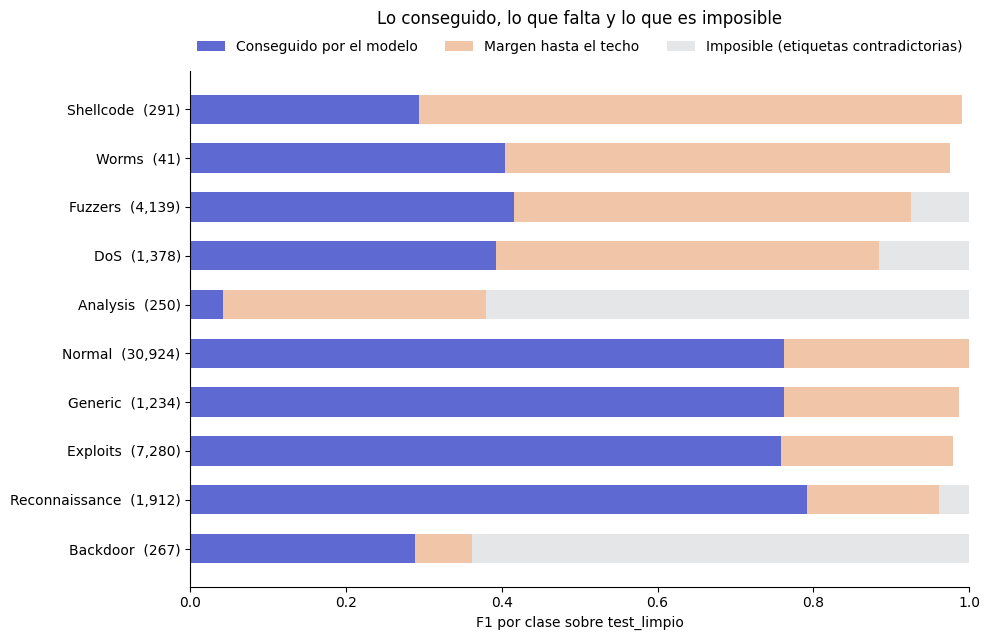

In [6]:
orden = comparacion.sort_values("margen").index
posicion = np.arange(len(orden))

fig, ax = plt.subplots(figsize=(10, 6.5))

# Cada clase se dibuja como el tramo conseguido más el tramo que falta.
ax.barh(posicion, comparacion.loc[orden, "f1_modelo"], 0.6,
        color=ACENTO, label="Conseguido por el modelo")
ax.barh(posicion, comparacion.loc[orden, "margen"], 0.6,
        left=comparacion.loc[orden, "f1_modelo"], color=AVISO, alpha=0.45,
        label="Margen hasta el techo")

# Lo que queda a la derecha del techo es imposible por contradicciones.
for i, clase in enumerate(orden):
    maximo = comparacion.loc[clase, "f1_maximo"]
    if maximo < 0.97:
        ax.barh(i, 1 - maximo, 0.6, left=maximo, color=GRIS, alpha=0.22,
                label="Imposible (etiquetas contradictorias)" if i == 0 else None)

ax.set_yticks(posicion, [f"{c}  ({int(comparacion.loc[c, 'ejemplos']):,})" for c in orden])
ax.set_xlim(0, 1)
ax.set_xlabel("F1 por clase sobre test_limpio")
ax.set_title("Lo conseguido, lo que falta y lo que es imposible", pad=34)
# La leyenda va fuera del área de barras: casi todas llegan hasta el borde.
ax.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(RESULTADOS / "techo-por-clase.png", dpi=140)
plt.show()

### Qué se ve aquí — la conclusión se da la vuelta

La barra morada es lo conseguido, la naranja lo que falta hasta el techo, y la
gris lo que es **imposible** por contradicciones en las etiquetas.

**Solo dos clases tienen techo bajo:**

| Clase | f1 máximo | f1 del modelo | % del techo |
|---|---|---|---|
| `Analysis` | 0,379 | 0,042 | 11 % |
| `Backdoor` | 0,361 | 0,288 | **80 %** |

Su recall máximo alcanzable es **0,284 y 0,277**. Aunque existiera el modelo
perfecto, detectaría menos de un tercio de esos ataques. Eso **sí** es un límite
de los datos.

Y hay un detalle que cambia el diagnóstico: **`Backdoor` ya está al 80 % de su
techo.** No es una clase que el modelo lleve mal — es una clase que el dataset no
permite resolver, y el modelo está casi tan cerca como se puede llegar.

**Las demás clases tienen el techo casi intacto, y ahí el modelo se queda muy
corto:**

| Clase | f1 máximo | f1 del modelo | Margen |
|---|---|---|---|
| `Shellcode` | 0,991 | 0,293 | **0,698** |
| `Worms` | 0,976 | 0,404 | **0,572** |
| `Fuzzers` | 0,926 | 0,415 | 0,511 |
| `DoS` | 0,885 | 0,393 | 0,492 |

> **Corrección al paso 4.** Yo señalé a `Analysis` como el caso de límite de
> datos. Es cierto para `Analysis` y `Backdoor`, pero **el mayor margen
> desaprovechado está en `Shellcode` y `Worms`, que tienen techo casi perfecto**
> (0,99 y 0,98) y el modelo apenas raspa un tercio. Ahí no hay excusa de datos.

Falta comprobar una cosa antes de darlo por bueno: que la información para
distinguir esas clases **esté realmente en las características**.

In [7]:
# Qué proporción de las filas de cada clase cae sobre un vector ambiguo.
tabla_k = pd.DataFrame({"k": k_test.values, "y": y_test.values})
etiquetas_por_vector = tabla_k.groupby("k")["y"].nunique()
vectores_ambiguos = set(etiquetas_por_vector[etiquetas_por_vector > 1].index)
en_ambiguo = k_test.isin(vectores_ambiguos).values

ambiguedad = pd.DataFrame({
    "filas": [int((y_test == c).sum()) for c in CLASES],
    "en_vector_ambiguo": [int(((y_test == c) & en_ambiguo).sum()) for c in CLASES],
}, index=CLASES)
ambiguedad["%"] = (
    ambiguedad["en_vector_ambiguo"] / ambiguedad["filas"] * 100
).round(1)

ambiguedad.sort_values("%", ascending=False)

,filas,en_vector_ambiguo,%
Backdoor,267,210,78.7
Analysis,250,192,76.8
DoS,1378,254,18.4
Fuzzers,4139,246,5.9
Worms,41,2,4.9
Exploits,7280,272,3.7
Reconnaissance,1912,55,2.9
Shellcode,291,5,1.7
Generic,1234,18,1.5
Normal,30924,20,0.1


### El origen del techo bajo

Ahora se ve de dónde sale:

- **`Backdoor`: el 78,7 % de sus filas** está sobre un vector que también lleva
  otra etiqueta.
- **`Analysis`: el 76,8 %.**
- La siguiente es `DoS` con un 18,4 %, y a partir de ahí todo baja del 6 %.
  `Normal` está en el 0,1 %.

**Tres de cada cuatro filas de `Analysis` y `Backdoor` son indistinguibles de
otra cosa.** No es un problema de modelado: es que el dataset describe esas
conexiones con valores que también aparecen etiquetados de otra forma.

---

# 4. ¿Está la información en las características?

El modelo multiclase manda el 78 % de los `Worms` a `Exploits`. Hay dos
explicaciones posibles y llevan a sitios opuestos:

**(a)** Las características no contienen lo que diferencia un gusano de un
exploit. Entonces no hay nada que hacer.

**(b)** Sí lo contienen, pero el modelo multiclase no lo aprovecha porque
`Exploits` tiene 158 veces más ejemplos y arrastra todas las dudas.

Se distinguen con un experimento directo: **entrenar un clasificador binario solo
con esas dos clases y con el mismo número de ejemplos de cada una.** Sin
desequilibrio y sin las otras ocho clases compitiendo, si la información está
ahí, el clasificador la encontrará.

Se mide con dos cosas:

- **Balanced accuracy** — el acierto medio de las dos clases. Con 0,5 el modelo
  no distingue nada.
- **ROC AUC** — la probabilidad de que, tomando un ejemplo de cada clase, el
  modelo puntúe más alto al correcto. 0,5 es azar; 1,0 es separación perfecta.

Se incluyen **pares de control** que deberían salir bien (`Normal vs Exploits`)
para comprobar que el experimento mide lo que dice medir.

In [8]:
def separabilidad(a, b):
    """Entrena un binario equilibrado con dos clases y lo evalúa en test_limpio."""
    subconjunto = train[train[OBJETIVO].isin([a, b])]
    cuenta = subconjunto[OBJETIVO].value_counts()
    n = int(min(cuenta[a], cuenta[b]))

    equilibrado = pd.concat([
        subconjunto[subconjunto[OBJETIVO] == a].sample(n, random_state=SEMILLA),
        subconjunto[subconjunto[OBJETIVO] == b].sample(n, random_state=SEMILLA),
    ])
    prueba = test_limpio[test_limpio[OBJETIVO].isin([a, b])]

    binario = RandomForestClassifier(
        n_estimators=300, random_state=SEMILLA, n_jobs=-1
    ).fit(preparar(equilibrado), equilibrado[OBJETIVO])

    X_prueba = preparar(prueba)
    p = binario.predict(X_prueba)
    prob_b = binario.predict_proba(X_prueba)[:, list(binario.classes_).index(b)]

    return {
        "par": f"{a} vs {b}",
        "ejemplos_por_clase": n,
        "filas_prueba": len(prueba),
        "balanced_accuracy": round(balanced_accuracy_score(prueba[OBJETIVO], p), 3),
        "roc_auc": round(roc_auc_score((prueba[OBJETIVO] == b).astype(int), prob_b), 3),
    }


pares = [
    ("Worms", "Exploits"),
    ("Shellcode", "Fuzzers"),
    ("Backdoor", "Exploits"),
    ("Analysis", "Exploits"),
    ("DoS", "Exploits"),
    ("Analysis", "Backdoor"),
    ("Normal", "Exploits"),    # control: debe salir alto
    ("Generic", "Exploits"),   # control
]

binarios = pd.DataFrame([separabilidad(a, b) for a, b in pares]).set_index("par")
binarios.sort_values("roc_auc", ascending=False)

,ejemplos_por_clase,filas_prueba,balanced_accuracy,roc_auc
par,,,,
Normal vs Exploits,19360,38204,0.949,0.993
Worms vs Exploits,123,7321,0.934,0.983
Backdoor vs Exploits,1121,7547,0.945,0.977
Shellcode vs Fuzzers,954,4430,0.927,0.977
Analysis vs Exploits,1119,7530,0.863,0.956
Generic vs Exploits,1800,8514,0.859,0.956
DoS vs Exploits,3369,8658,0.772,0.851
Analysis vs Backdoor,1119,517,0.517,0.566


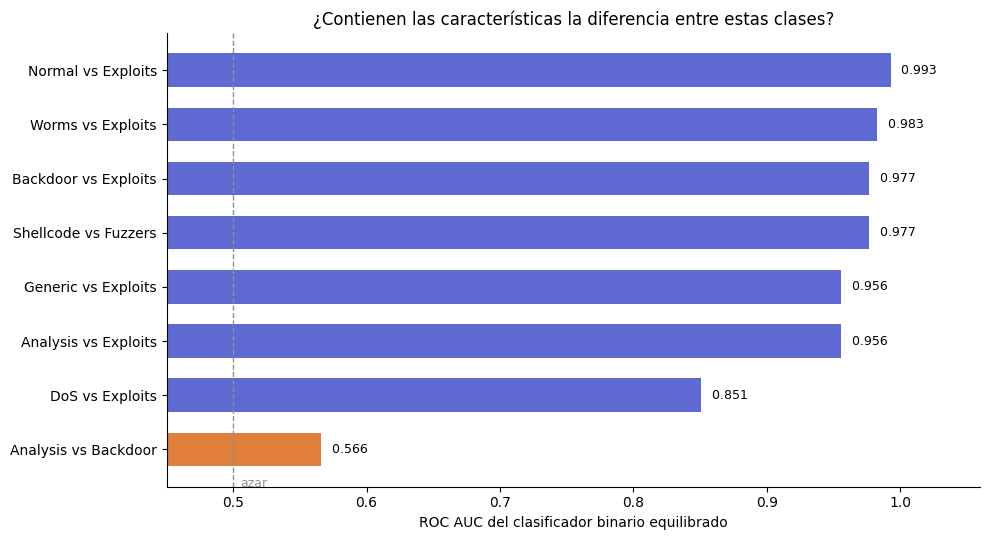

In [9]:
orden = binarios.sort_values("roc_auc").index
posicion = np.arange(len(orden))

fig, ax = plt.subplots(figsize=(10, 5.5))
colores = [AVISO if v < 0.70 else ACENTO for v in binarios.loc[orden, "roc_auc"]]
barras = ax.barh(posicion, binarios.loc[orden, "roc_auc"], 0.62, color=colores)

ax.axvline(0.5, color=GRIS, linestyle="--", linewidth=1)
ax.text(0.505, -0.7, "azar", fontsize=9, color=GRIS)

ax.bar_label(barras, labels=[f"  {v:.3f}" for v in binarios.loc[orden, "roc_auc"]],
             padding=2, fontsize=9)
ax.set_yticks(posicion, orden)
ax.set_xlim(0.45, 1.06)
ax.set_xlabel("ROC AUC del clasificador binario equilibrado")
ax.set_title("¿Contienen las características la diferencia entre estas clases?")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(RESULTADOS / "separabilidad-binaria.png", dpi=140)
plt.show()

### Qué se ve aquí — el resultado más útil del cuaderno

**`Worms vs Exploits`: ROC AUC 0,983.** Balanced accuracy 0,934.

Con solo **123 gusanos** y el mismo número de exploits, un clasificador binario
los separa casi perfectamente. **La información estaba ahí todo el tiempo.**

El modelo multiclase, en cambio, manda el 78 % de los `Worms` a `Exploits`. No
falla por falta de señal: falla porque con 19 360 ejemplos de `Exploits` frente a
123 de `Worms` —**157 veces más**— cualquier duda se resuelve a favor del
mayoritario. **Es la hipótesis (b).**

Lo mismo en `Shellcode vs Fuzzers` (0,977) y `Backdoor vs Exploits` (0,977).

**Y una excepción que lo explica todo: `Analysis vs Backdoor` da ROC AUC 0,566 y
balanced accuracy 0,517.** Prácticamente una moneda al aire.

Es el único par del experimento que no se separa, y es revelador porque ambas
**sí** se distinguen de `Exploits` por separado (0,956 y 0,977). No es que
`Analysis` y `Backdoor` sean clases difíciles en general: **es que son
indistinguibles entre sí**.

Eso cierra el círculo con el apartado anterior: sus vectores ambiguos (76,8 % y
78,7 %) se contradicen sobre todo **el uno con el otro**.

> **En UNSW-NB15, `Analysis` y `Backdoor` no son dos clases separables.** Son la
> misma región del espacio de características con dos nombres.

Los controles confirman que el experimento mide lo que dice: `Normal vs Exploits`
da 0,993 y `Generic vs Exploits` 0,956, como era de esperar.

---

# 5. Consecuencia práctica: fusionar `Analysis` y `Backdoor`

Si dos clases no se distinguen, mantenerlas separadas **penaliza al modelo por un
error que no puede evitar** — y el f1_macro, que las pondera igual que a las
demás, arrastra dos ceros casi garantizados.

Se calcula qué pasaría al tratarlas como una sola categoría. **No es hacer trampa
si se declara**: es reconocer una limitación del etiquetado en lugar de fingir
que no está.

In [10]:
FUSION = {"Analysis": "Analysis/Backdoor", "Backdoor": "Analysis/Backdoor"}

y_test_f = y_test.replace(FUSION)
pred_modelo_f = pd.Series(pred_modelo, index=y_test.index).replace(FUSION)
CLASES_F = sorted(y_test_f.unique())

# El oráculo se recalcula sobre las etiquetas ya fusionadas.
mayoritaria_f = (
    pd.DataFrame({"k": k_test.values, "y": y_test_f.values})
    .groupby(["k", "y"]).size().reset_index(name="n")
    .sort_values("n", ascending=False).drop_duplicates("k").set_index("k")["y"]
)
pred_oraculo_f = k_test.map(mayoritaria_f).values

efecto = pd.DataFrame([
    {
        "escenario": "10 clases",
        "f1_macro_modelo": f1_score(y_test, pred_modelo, average="macro",
                                    labels=CLASES, zero_division=0),
        "f1_macro_techo": f1_score(y_test, pred_oraculo, average="macro",
                                   labels=CLASES, zero_division=0),
    },
    {
        "escenario": "9 clases (Analysis+Backdoor fusionadas)",
        "f1_macro_modelo": f1_score(y_test_f, pred_modelo_f, average="macro",
                                    labels=CLASES_F, zero_division=0),
        "f1_macro_techo": f1_score(y_test_f, pred_oraculo_f, average="macro",
                                   labels=CLASES_F, zero_division=0),
    },
]).set_index("escenario").round(4)

efecto["% del techo"] = (
    efecto["f1_macro_modelo"] / efecto["f1_macro_techo"] * 100
).round(1)
efecto

,f1_macro_modelo,f1_macro_techo,% del techo
escenario,,,
10 clases,0.4911,0.8446,58.1
9 clases (Analysis+Backdoor fusionadas),0.5275,0.9332,56.5


### Qué se ve aquí — y por qué fusionar no es el atajo que parecía

La fusión sube el f1_macro del modelo de **0,491 a 0,528**. Visto solo, parece una
mejora de 3,7 puntos conseguida sin tocar nada.

Pero el techo sube **más**: de 0,845 a **0,933**. Y ahí está lo interesante:

| Escenario | Modelo | Techo | **% del techo** |
|---|---|---|---|
| 10 clases | 0,491 | 0,845 | **58,1 %** |
| 9 clases (fusionadas) | 0,528 | 0,933 | **56,5 %** |

**El porcentaje del techo alcanzado no sube: baja un poco.** Fusionar quita del
promedio dos clases con techo bajo, así que sube tanto la nota del modelo como la
nota máxima — pero el modelo no se acerca más a su límite.

> **Conclusión:** la fusión está justificada porque `Analysis` y `Backdoor` no son
> separables (ROC AUC 0,566) y mantenerlas por separado es fingir una distinción
> que el dataset no soporta. Pero **no es una mejora del modelo**, y presentar el
> 0,528 como un avance sería engañoso.

Esa última columna, el **porcentaje del techo alcanzado**, es la métrica que hay
que llevarse de este cuaderno: dice cómo de bueno es el modelo con independencia
de lo difícil que sea el problema, y no se deja mover por trucos de agrupación.

Con un 58 % del techo, **el margen real sigue intacto.**

---

# Resumen

## El techo, por conjunto

| Conjunto | % filas ambiguas | Accuracy máxima |
|---|---|---|
| `test_oficial` | 13,07 % | 0,9307 |
| **`train`** | **6,32 %** | 0,9512 |
| `test_limpio` | 2,67 % | **0,9796** |
| Dataset entero | 10,50 % | 0,9400 |

## El techo frente a la realidad

| | Modelo (paso 4) | Oráculo | Distancia |
|---|---|---|---|
| accuracy | 0,662 | 0,980 | 0,318 |
| **f1_macro** | **0,491** | **0,845** | **0,354** |

## Los cuatro hallazgos

1. **Las etiquetas contradictorias no son lo que limita al modelo.** Ponen el
   techo del f1_macro en 0,845; el modelo va por 0,491. **Quedan 35 puntos que no
   son culpa de los datos.**

2. **Solo dos clases tienen techo bajo: `Analysis` (0,379) y `Backdoor`
   (0,361)**, porque el 77-79 % de sus filas está sobre vectores que llevan otra
   etiqueta. `Backdoor` ya alcanza el **80 % de su techo**: no es una clase que
   el modelo lleve mal, es una que el dataset no permite resolver.

3. **Donde más margen se desaprovecha es en `Shellcode` (0,293 de un techo de
   0,991) y `Worms` (0,404 de 0,976).** Corrige lo que escribí al cerrar el paso
   4: ahí no hay límite de datos, hay modelo mejorable.

4. **La información sí está en las características.** Un binario equilibrado
   separa `Worms` de `Exploits` con **ROC AUC 0,983** usando solo 123 gusanos. El
   multiclase falla por el desequilibrio, no por falta de señal. La única
   excepción real es **`Analysis vs Backdoor`: ROC AUC 0,566**, indistinguibles.

## Siguiente paso

Los hallazgos 3 y 4 juntos dicen qué hacer: **la señal existe y el modelo no la
está usando**. Toca atacar eso:

- **Un modelo de *boosting***, que suele aprovechar mejor las clases pequeñas en
  datos tabulares que un bosque aleatorio.
- **Estrategia uno-contra-resto**, apoyada en que los binarios equilibrados
  funcionan tan bien (AUC 0,98) mientras el multiclase no.
- **Reportar también con `Analysis` y `Backdoor` fusionadas**, declarándolo — y
  sin venderlo como mejora, porque el porcentaje del techo no sube.

Y una métrica nueva para el informe final: **el porcentaje del techo alcanzado**
(ahora **58,1 %**), que dice cómo de bueno es el modelo con independencia de lo
difícil que sea el problema.
